In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scienceplots
import matplotlib as mpl
from tqdm import tqdm
from scipy.stats.mstats import ttest_onesamp
from joblib import Parallel, delayed
from tqdm import tqdm


#mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use(['science','notebook'])
plt.rcParams['font.size'] = 18

colors = ["black","red", "blue"]

In [82]:
time = np.arange(5000)*10.0/1000

data_central   = np.loadtxt("pickles_mean/central_mean_and_std.txt")
exemple_central = np.loadtxt("pickles_mean/central_exemple.txt")

data_1stshell = np.loadtxt("pickles_mean/1stshell_mean_and_std.txt")
exemple_1stshell = np.loadtxt("pickles_mean/1stshell_exemple.txt")

data_2ndshell = np.loadtxt("pickles_mean/2ndshell_mean_and_std.txt")
exemple_2ndshell = np.loadtxt("pickles_mean/2ndshell_exemple.txt")

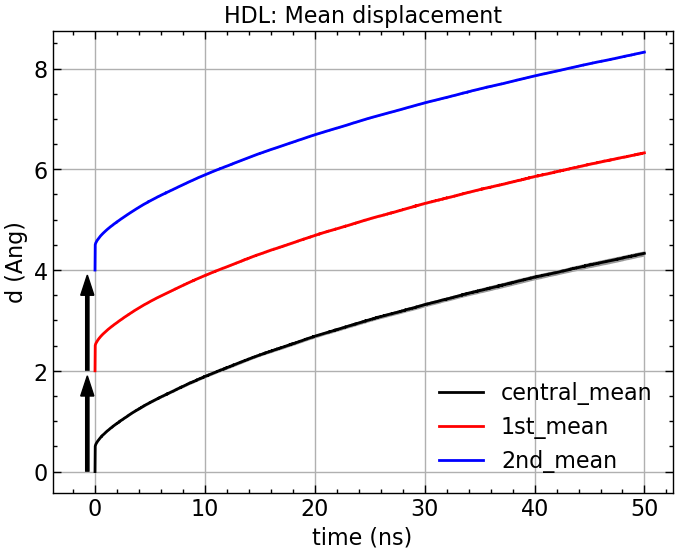

In [83]:
fig, ax = plt.subplots()

#ax.set_xscale('log')
ax.grid()
ax.set_title("HDL: Mean displacement")
ax.set_xlabel("time (ns)")
ax.set_ylabel("d (Ang)")

ax.plot(time,data_central[:,0], color = colors[0], label="central_mean")
ax.fill_between(time,data_central[:,0]+data_central[:,1],data_central[:,0]-data_central[:,1], color =  colors[0], lw =0, alpha = 0.4)
#ax.plot(time, exemple_central[0], '--' )
#ax.plot(time, exemple_central[1], '-.' )
#ax.plot(time, exemple_central[2], ':' )

ax.plot(time,data_1stshell[:,0]+2, color = colors[1], label="1st_mean")
ax.fill_between(time,data_1stshell[:,0]+data_1stshell[:,1]+2,data_1stshell[:,0]-data_1stshell[:,1]+2, color =  colors[1], lw =0, alpha = 0.4)
ax.arrow(-700/1000,0,dx=0, dy=1.9, width=300/1000, length_includes_head=True, head_length=0.4, head_width=200*6/1000, color =  colors[0])
#ax.plot(time, exemple_central[0], '--' )
#ax.plot(time, exemple_central[1], '-.' )
#ax.plot(time, exemple_central[2], ':' )
ax.plot(time,data_2ndshell[:,0]+4, color = colors[2], label="2nd_mean")
ax.fill_between(time,data_2ndshell[:,0]+data_2ndshell[:,1]+4,data_2ndshell[:,0]-data_2ndshell[:,1]+4, color =  colors[2], lw =0, alpha = 0.4)
ax.arrow(-700/1000,2,dx=0, dy=1.9, width=300/1000, length_includes_head=True, head_length=0.4, head_width=200*6/1000, color =  colors[0])

ax.legend()

plt.show()


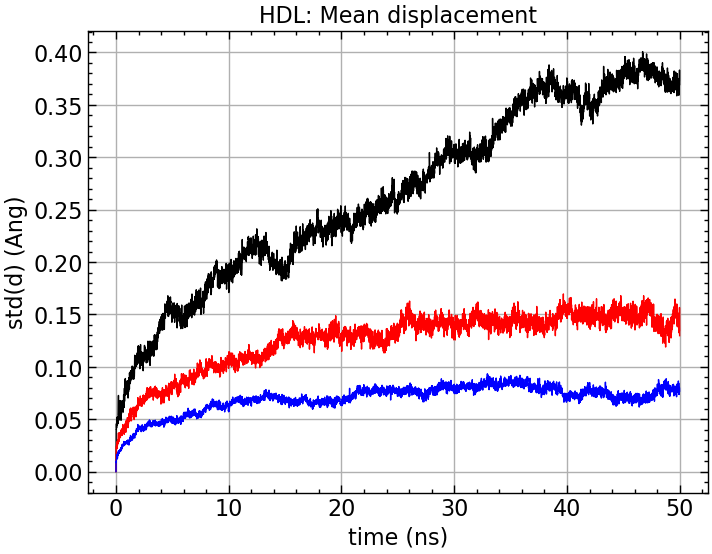

In [84]:
fig, ax = plt.subplots()

#ax.set_xscale('log')
ax.grid()
ax.set_title("HDL: Mean displacement")
ax.set_xlabel("time (ns)")
ax.set_ylabel("std(d) (Ang)")

#ax.set_yscale('log')

ax.plot(time, data_central[:,1]*np.sqrt(50), color =  colors[0], lw =1)
#ax.plot(time, exemple_central[0], '--' )
#ax.plot(time, exemple_central[1], '-.' )
#ax.plot(time, exemple_central[2], ':' )

ax.plot(time, data_1stshell[:,1]*np.sqrt(50), color =  colors[1], lw =1)
#ax.plot(time, exemple_central[0], '--' )
#ax.plot(time, exemple_central[1], '-.' )
#ax.plot(time, exemple_central[2], ':' )
ax.plot(time, data_2ndshell[:,1]*np.sqrt(50), color =  colors[2], lw =1)


plt.show()


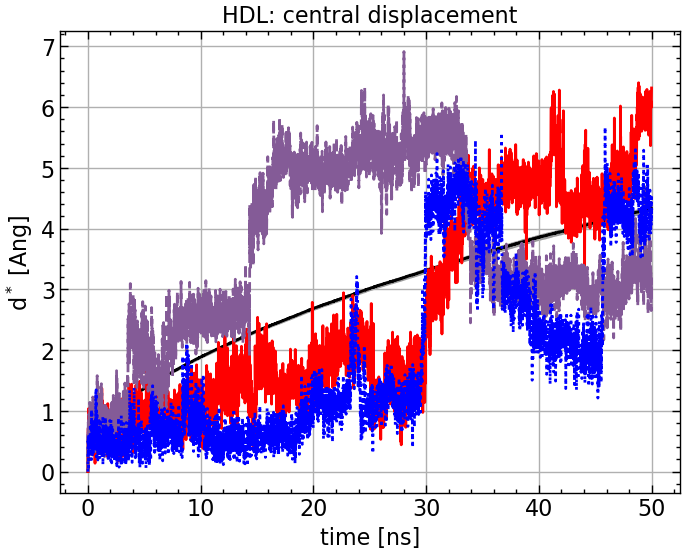

In [107]:
fig, ax = plt.subplots()

#ax.set_xscale('log')
ax.plot(time,data_central[:,0], color = colors[0], label="central_mean")
ax.fill_between(time,data_central[:,0]+data_central[:,1],data_central[:,0]-data_central[:,1], color =  colors[0], lw =0, alpha = 0.4)

ax.plot(time, exemple_central[1], '-', color = colors[1], lw = 2)
ax.plot(time, exemple_central[0],  '--', color='C4' ,  lw = 2)
ax.plot(time, exemple_central[2], ':' , color = colors[2], lw = 2)

ax.set_title("HDL: central displacement")
ax.set_xlabel("time [ns]")
ax.set_ylabel(u"d$^*$ [Ang]")

ax.grid() 
plt.show()

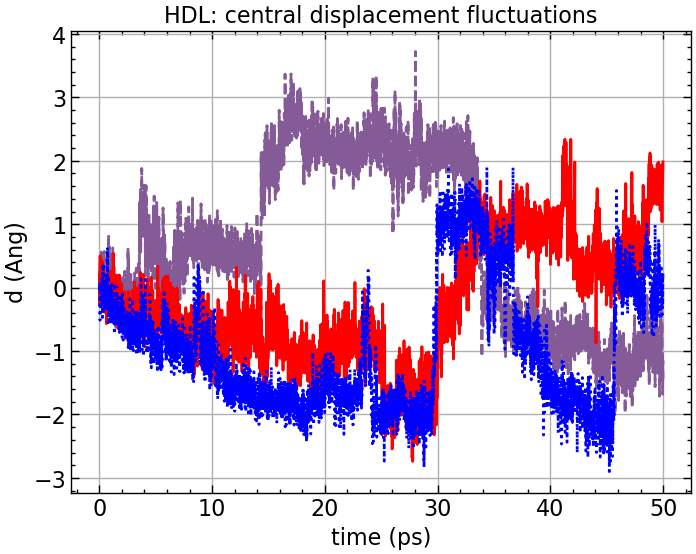

In [108]:
fig, ax = plt.subplots()

#ax.set_xscale('log')
#ax.plot(time,data_central[:,0], color = colors[0], label="central_mean")
#ax.fill_between(time,data_central[:,0]+data_central[:,1],data_central[:,0]-data_central[:,1], color =  colors[0], lw =0, alpha = 0.4)

ax.set_title("")

ax.plot(time, exemple_central[0] - data_central[:,0], '--', color = 'C4', lw = 2)
ax.plot(time, exemple_central[1] - data_central[:,0], '-', color = colors[1], lw = 2)
ax.plot(time, exemple_central[2] - data_central[:,0], ':' , color = colors[2], lw = 2)

ax.set_title("HDL: central displacement fluctuations")
ax.set_xlabel("time (ps)")
ax.set_ylabel("d (Ang)")


ax.grid()
plt.show()

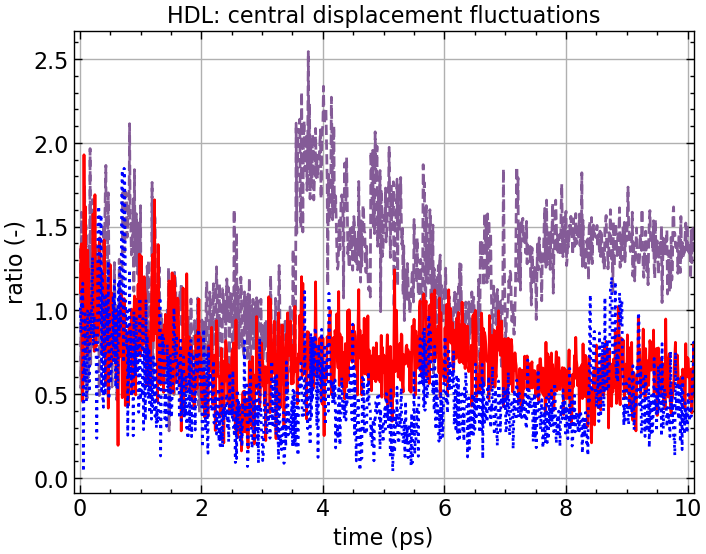

In [109]:
fig, ax = plt.subplots()

#ax.set_xscale('log')
#ax.plot(time,data_central[:,0], color = colors[0], label="central_mean")
#ax.fill_between(time,data_central[:,0]+data_central[:,1],data_central[:,0]-data_central[:,1], color =  colors[0], lw =0, alpha = 0.4)

ax.set_title("")

ax.plot(time[1:], exemple_central[0][1:] / data_central[1:,0], '--', color = 'C4', lw = 2)
ax.plot(time[1:], exemple_central[1][1:] / data_central[1:,0], '-', color = colors[1], lw = 2)
ax.plot(time[1:], exemple_central[2][1:] / data_central[1:,0], ':' , color = colors[2], lw = 2)

ax.set_title("HDL: central displacement fluctuations")
ax.set_xlabel("time (ps)")
ax.set_ylabel("ratio (-)")
ax.set_xlim((-0.1,10.1))


ax.grid()
plt.show()

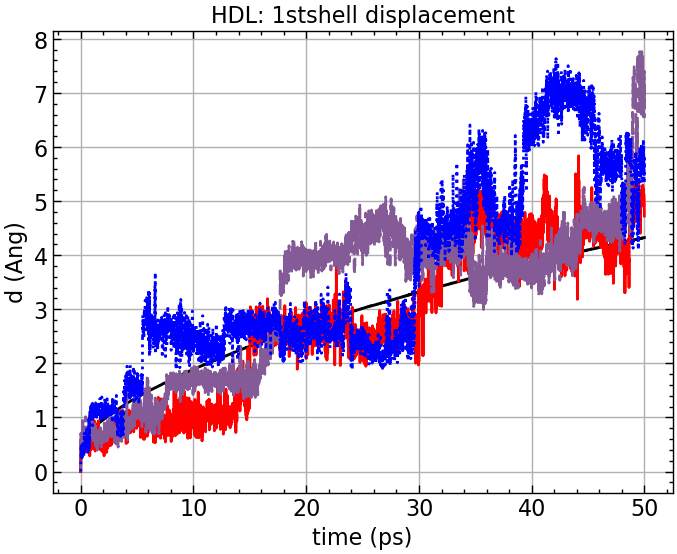

In [110]:
fig, ax = plt.subplots()

#ax.set_xscale('log')
ax.plot(time,data_1stshell[:,0], color = colors[0], label="1st_mean")
ax.fill_between(time,data_1stshell[:,0]+data_1stshell[:,1],data_1stshell[:,0]-data_1stshell[:,1], color =  colors[0], lw =0, alpha = 0.4)

ax.plot(time, exemple_1stshell[1], '-', color = colors[1], lw = 2)
ax.plot(time, exemple_1stshell[0],  '--', color='C4' ,  lw = 2)
ax.plot(time, exemple_1stshell[2], ':' , color = colors[2], lw = 2)

ax.set_title("HDL: 1stshell displacement")
ax.set_xlabel("time (ps)")
ax.set_ylabel("d (Ang)")

ax.grid() 
plt.show()

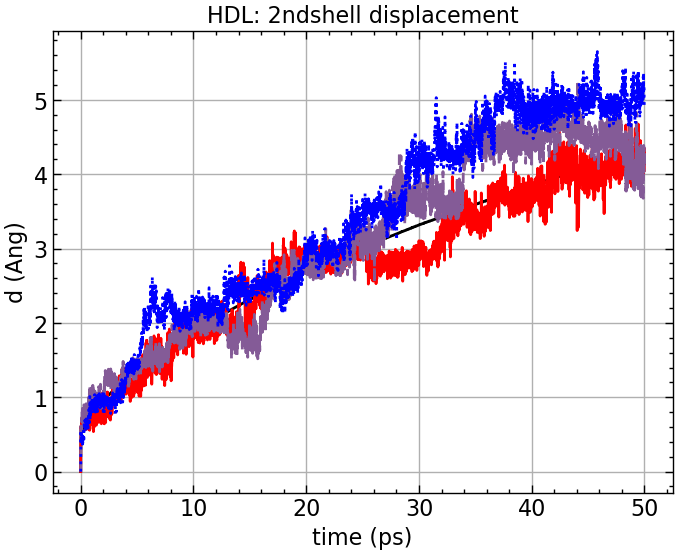

In [111]:
fig, ax = plt.subplots()

#ax.set_xscale('log')
ax.plot(time,data_2ndshell[:,0], color = colors[0], label="2nd_mean")
ax.fill_between(time,data_2ndshell[:,0]+data_2ndshell[:,1],data_2ndshell[:,0]-data_2ndshell[:,1], color =  colors[0], lw =0, alpha = 0.4)

ax.plot(time, exemple_2ndshell[1], '-', color = colors[1], lw = 2)
ax.plot(time, exemple_2ndshell[0],  '--', color='C4' ,  lw = 2)
ax.plot(time, exemple_2ndshell[2], ':' , color = colors[2], lw = 2)

ax.set_title("HDL: 2ndshell displacement")
ax.set_xlabel("time (ps)")
ax.set_ylabel("d (Ang)")

ax.grid() 
plt.show()

In [112]:
# time = np.arange(5000)*10000.0/1000 #(ps)

# data_central   = np.loadtxt("pickles_mean/central_d2_mean_and_std.txt")
# exemple_central = np.loadtxt("pickles_mean/central_d2_exemple.txt")

# fig, ax = plt.subplots()

# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.grid()
# ax.set_title("HDL: Mean Square Displacement")
# ax.set_xlabel("time (ps)")
# ax.set_ylabel("d$^2$ ($\\AA^2$)")

# ax.plot(time,data_central[:,0], color = colors[0], label="central_mean")
# ax.fill_between(time,data_central[:,0]+data_central[:,1],data_central[:,0]-data_central[:,1], color =  colors[0], lw =0, alpha = 0.4)

# m,b = np.polyfit(time[200:],data_central[200:,0]  , 1)
# ax.plot(time,b+m*time, color = colors[2], label=f"fit: D = {m/6:1.3e}"+ " $\mathrm{\\AA}^2.ps^{-1}$ " )
# #ax.plot(time, exemple_central[0], '--' )
# #ax.plot(time, exemple_central[1], '-.' )
# #ax.plot(time, exemple_central[2], ':' )
# ax.legend()

# plt.show()

In [113]:
def read_X_Y_d(Ntrajs, seed, t, E, tau_e, njobs, traj_numbers, means, stds):

    (d_center, d_1stshell, d_2ndshell) = (
        np.swapaxes(Parallel(n_jobs=njobs)(delayed(read_files_d)
            (namefile=f'./pickles_d/d_cent_1st_2nd_seed{seed}_traj{traj_number}.p',
                t=t, E=E, tau_e=tau_e, means=means, stds=stds) for traj_number in traj_numbers), axis1=0, axis2=1)
    )
    d_center = d_center.reshape((Ntrajs,-1))
    d_1stshell = d_1stshell.reshape((Ntrajs,-1))
    d_2ndshell = d_2ndshell.reshape((Ntrajs,-1))

    return d_center, d_1stshell, d_2ndshell

def read_X_Y_dipole(Ntrajs, seed, t, E, tau_e, njobs, stds, traj_numbers):

    assert len(stds) == 3, "Error: wrong number of stds"
    (dipoles_center, dipoles_1stshell, dipoles_2ndshell) = (
        np.swapaxes(Parallel(n_jobs=njobs)(delayed(read_files_dipole)
            (namefile=f'./pickles_dipoles/dipoles_cent_1st_2nd_seed{seed}_traj{(traj_number)}.p',
                t=t, E=E, tau_e=tau_e, stds=stds) for traj_number in traj_numbers), axis1=0, axis2=1)
    )
    dipoles_center =  dipoles_center.reshape((Ntrajs,-1))
    dipoles_1stshell = dipoles_1stshell.reshape((Ntrajs,-1))
    dipoles_2ndshell = dipoles_2ndshell.reshape((Ntrajs,-1))

    return dipoles_center, dipoles_1stshell, dipoles_2ndshell


def read_files_dipole(namefile, E, tau_e, stds):
    dipoles_center_temp, dipoles_1stshell_temp, dipoles_2ndshell_temp = pickle.load(open(namefile, 'rb'))

    dipoles_center_temp /=  ((stds[0].max()) * np.sqrt(3))
    dipoles_1stshell_temp /=  ((stds[1].max()) * np.sqrt(3))
    dipoles_2ndshell_temp /=  ((stds[2].max()) * np.sqrt(3))

    dipoles_center=np.zeros(((len(dipoles_center_temp)-E)//tau_e,E))
    dipoles_1stshell=np.zeros(((len(dipoles_center_temp)-E)//tau_e,E))
    dipoles_2ndshell=np.zeros(((len(dipoles_center_temp)-E)//tau_e,E))
    
    for t in range(0,len(dipoles_center_temp)-E, tau_e):
        embed_times = np.arange(t, t+E, tau_e)
        dipoles_center[t] = +dipoles_center_temp[embed_times]
        dipoles_1stshell[t] = +dipoles_1stshell_temp[embed_times]
        dipoles_2ndshell[t] = +dipoles_2ndshell_temp[embed_times]

    return np.array((dipoles_center, dipoles_1stshell, dipoles_2ndshell))



def read_files_d(namefile, E, tau_e, stds, means):
    d_center_temp, d_1stshell_temp, d_2ndshell_temp = pickle.load(open(namefile, 'rb'))

    d_center -= means[0]
    d_1stshell -= means[1]
    d_2ndshell -= means[2]

    d_center_temp /=  stds[0] 
    d_1stshell_temp /=  stds[1]
    d_2ndshell_temp /=  stds[2]

    d_center=np.zeros(((len(d_center_temp)-E)//tau_e,E))
    d_1stshell=np.zeros(((len(d_center_temp)-E)//tau_e,E))
    d_2ndshell=np.zeros(((len(d_center_temp)-E)//tau_e,E))
    
    for t in range(0,len(d_center_temp)-E, tau_e):
        embed_times = np.arange(t, t+E, tau_e)
        d_center[t] = +d_center_temp[embed_times]
        d_1stshell[t] = +d_1stshell_temp[embed_times]
        d_2ndshell[t] = +d_2ndshell_temp[embed_times]

    return np.array((d_center, d_1stshell, d_2ndshell))

def compute_scaling_factors_dipole(namefile):

    dipoles_center, dipoles_1stshell, dipoles_2ndshell = pickle.load(open(namefile, 'rb'))

    stds = [dipoles_center.std(axis=0, keepdims=True),
            dipoles_1stshell.std(axis=0, keepdims=True),
            dipoles_2ndshell.std(axis=0, keepdims=True)]

    return stds


In [114]:
Nframes = 5000
Ntrajs = 2000
tau_e = 1
E = 10
seed = 1
njobs = 8
traj_numbers = np.loadtxt("Datatrajs_frame_numbers.txt", dtype='int')

d_means = np.zeros((3,Nframes))
d_stds = np.zeros((3,Nframes))

d_means[0] = np.loadtxt("pickles_mean/central_mean_and_std.txt")[:,0]
d_means[1] = np.loadtxt("pickles_mean/1stshell_mean_and_std.txt")[:,0]
d_means[2] = np.loadtxt("pickles_mean/2ndshell_mean_and_std.txt")[:,0]

d_stds[0] = np.loadtxt("pickles_mean/central_mean_and_std.txt")[:,1]*np.sqrt(50)
d_stds[1] = np.loadtxt("pickles_mean/1stshell_mean_and_std.txt")[:,1]*np.sqrt(50)
d_stds[2] = np.loadtxt("pickles_mean/2ndshell_mean_and_std.txt")[:,1]*np.sqrt(50)

stds_dipole = compute_scaling_factors_dipole(f'./pickles_dipoles/dipoles_cent_1st_2nd_seed1_traj{traj_numbers[0]}.p')

(   d_center_t0,
    d_1stshell_t0,
    d_2ndshell_t0
) = (
    read_X_Y_d( 
        Ntrajs = Ntrajs,
        seed = seed,
        E = E,
        tau_e = tau_e,
        njobs = njobs,
        stds = d_stds,
        means = d_means,
        traj_numbers = traj_numbers
        )
)

(   dipoles_center_t0, 
    dipoles_1stshell_t0, 
    dipoles_2ndshell_t0
) = (
    read_X_Y_dipole(
        Ntrajs = Ntrajs,
        seed = seed,
        E = E,
        tau_e = tau_e,
        njobs = njobs,
        stds = stds_dipole,
        traj_numbers = traj_numbers
        )
)



FileNotFoundError: [Errno 2] No such file or directory: './pickles_dipoles/dipoles_cent_1st_2nd_seed1_traj1.p'